# EDA — Calidad del Aire Madrid

Análisis exploratorio del dataset histórico de calidad del aire de Madrid (2018-2026).  
**Dataset**: 24 estaciones, centrado únicamente en los contaminantes: Monóxido de nitrógeno (NO, magnitud 7) y Ozono (O3, magnitud 14), con mediciones horarias.

Diccionario de contaminantes:

| Código | Abreviatura | Contaminante |
|---|---|---|
| 1 | SO2 | Dióxido de azufre |
| 6 | CO | Monóxido de carbono |
| 7 | NO | Monóxido de nitrógeno |
| 8 | NO2 | Dióxido de nitrógeno |
| 9 | PM2.5 | Partículas en suspensión < 2.5 µm |
| 10 | PM10 | Partículas en suspensión < 10 µm |
| 12 | NOx | Óxidos de nitrógeno |
| 14 | O3 | Ozono |
| 20 | TOL | Tolueno |
| 30 | BEN | Benceno |
| 35 | EBE | Etilbenceno |
| 37 | MXY | m-Xileno |
| 38 | PXY | p-Xileno |
| 39 | OXY | o-Xileno |
| 42 | TCH | Hidrocarburos totales |
| 43 | CH4 | Metano |
| 44 | NMHC | Hidrocarburos no metánicos |
| 431 | MPX | m+p-Xileno |


## 0. Configuración del Notebook
Importaremos todas las librerías y funciones que vemos relevantes para el notebook que vamos a crear. Lo ideal sería tener todas las importaciones juntas, de tal manera que se puedan controlar de manera sencilla.

### Importación de librerías

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### Definición de constantes

In [2]:
# Ruta al dataset
PATH_DATASET = "../data/raw/datos_completos_2018_2026.csv"

## 1. Lectura y procesado de datos
Leemos ya analizamos el dataset para hacer las transformaciones necesarias.

In [3]:
# Cargar el dataset
df = pd.read_csv(PATH_DATASET, sep=';')

# Filtrar para conservar solo los contaminantes NO (7) y O3 (14)
df = df[df['MAGNITUD'].isin([7, 14])].copy()

In [4]:
# Mostrar las primeras filas del dataset
df.head()

,PROVINCIA,MUNICIPIO,ESTACION,MAGNITUD,PUNTO_MUESTREO,ANO,MES,DIA,H01,V01,...,H20,V20,H21,V21,H22,V22,H23,V23,H24,V24
2,28,79,4,7,28079004_7_8,2018,1,1,2.00,V,...,4.0,V,3.00,V,2.00,V,2.0,V,1.00,V
7,28,79,8,7,28079008_7_8,2018,1,1,6.00,V,...,17.0,V,22.00,V,18.00,V,15.0,V,4.00,V
12,28,79,8,14,28079008_14_6,2018,1,1,56.22,V,...,31.4,V,27.51,V,27.52,V,32.5,V,46.38,V
19,28,79,11,7,28079011_7_8,2018,1,1,3.00,V,...,3.0,V,4.00,V,2.00,V,2.0,V,5.00,V
26,28,79,16,7,28079016_7_8,2018,1,1,1.00,V,...,2.0,V,2.00,V,6.00,V,6.0,V,3.00,V


In [5]:
# Mostrar las dimensiones del dataset
print(f"Dimensiones del dataset: {df.shape}")

Dimensiones del dataset: (112741, 56)


In [6]:
# Mostrar información general del dataset
df.info()

<class 'pandas.DataFrame'>
Index: 112741 entries, 2 to 417626
Data columns (total 56 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PROVINCIA       112741 non-null  int64  
 1   MUNICIPIO       112741 non-null  int64  
 2   ESTACION        112741 non-null  int64  
 3   MAGNITUD        112741 non-null  int64  
 4   PUNTO_MUESTREO  112741 non-null  str    
 5   ANO             112741 non-null  int64  
 6   MES             112741 non-null  int64  
 7   DIA             112741 non-null  int64  
 8   H01             112741 non-null  float64
 9   V01             112741 non-null  str    
 10  H02             112741 non-null  float64
 11  V02             112741 non-null  str    
 12  H03             112741 non-null  float64
 13  V03             112741 non-null  str    
 14  H04             112741 non-null  float64
 15  V04             112741 non-null  str    
 16  H05             112741 non-null  float64
 17  V05             112741 non

In [7]:
# Cuantas provincias, municipios, estaciones, magnitudes y años únicos hay en el dataset
num_provincias = df['PROVINCIA'].nunique()
num_municipios = df['MUNICIPIO'].nunique()
num_estaciones = df['ESTACION'].nunique()
num_magnitudes = df['MAGNITUD'].nunique()
num_años = df['ANO'].nunique()

print(f"Número de provincias únicas: {num_provincias}")
print(f"Número de municipios únicos: {num_municipios}")
print(f"Número de estaciones únicas: {num_estaciones}")
print(f"Número de magnitudes únicas: {num_magnitudes}")
print(f"Número de años únicos: {num_años}")

Número de provincias únicas: 1
Número de municipios únicos: 1
Número de estaciones únicas: 24
Número de magnitudes únicas: 2
Número de años únicos: 9


In [8]:
# Descripción estadística de las columnas numéricas
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
PROVINCIA,112741.0,28.000000,0.000000,28.0,28.00,28.00,28.00,28.0
MUNICIPIO,112741.0,79.000000,0.000000,79.0,79.00,79.00,79.00,79.0
ESTACION,112741.0,37.325463,17.717817,4.0,18.00,39.00,55.00,60.0
MAGNITUD,112741.0,9.517531,3.359294,7.0,7.00,7.00,14.00,14.0
ANO,112741.0,2021.643723,2.414316,2018.0,2020.00,2022.00,2024.00,2026.0
MES,112741.0,6.357767,3.475539,1.0,3.00,6.00,9.00,12.0
DIA,112741.0,15.717556,8.793942,1.0,8.00,16.00,23.00,31.0
H01,112741.0,23.113305,32.359175,-3.0,1.00,4.00,43.08,507.0
H02,112741.0,21.738023,30.473474,-3.0,1.00,3.00,42.00,748.5
H03,112741.0,20.613743,28.994668,-3.0,1.00,2.00,40.00,968.7


## 2. Análisis de flags de validez

Las columnas `V01`–`V24` indican si cada lectura horaria es válida (`V`) o no válida (`N`).  
Analizamos el porcentaje de datos inválidos a nivel global, por magnitud y por estación.

In [9]:
# Calcular el porcentaje de lecturas inválidas por cada columna V1 a V24
v_cols = ['V01', 'V02', 'V03', 'V04', 'V05', 'V06', 'V07', 'V08', 'V09', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24']
print(v_cols)

# Porcentaje global de lecturas inválidas
total_lecturas = df.shape[0] * 24
total_invalidas = (df[v_cols] == 'N').sum().sum()
pct_global = total_invalidas / total_lecturas * 100

print(f"Total lecturas:   {total_lecturas:,}")
print(f"Lecturas inválidas: {total_invalidas:,} ({pct_global:.2f}%)")

['V01', 'V02', 'V03', 'V04', 'V05', 'V06', 'V07', 'V08', 'V09', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24']
Total lecturas:   2,705,784
Lecturas inválidas: 30,855 (1.14%)


In [10]:
# Porcentaje de inválidos por magnitud
invalidas_por_magnitud = (
    df[v_cols]
    .eq('N')
    .sum(axis=1)
)

resumen_magnitud = df[['MAGNITUD']].copy()
resumen_magnitud['invalidas'] = invalidas_por_magnitud
resumen_magnitud['total'] = 24

resultado = (
    resumen_magnitud
    .groupby('MAGNITUD')[['invalidas', 'total']]
    .sum()
)
resultado['pct_invalidas'] = (resultado['invalidas'] / resultado['total'] * 100).round(2)
resultado.sort_values('pct_invalidas', ascending=False)

,invalidas,total,pct_invalidas
MAGNITUD,,,
14,13243,973128,1.36
7,17612,1732656,1.02


In [11]:
# Porcentaje de inválidos por estación
resumen_estacion = df[['ESTACION']].copy()
resumen_estacion['invalidas'] = invalidas_por_magnitud
resumen_estacion['total'] = 24

resultado_estacion = (
    resumen_estacion
    .groupby('ESTACION')[['invalidas', 'total']]
    .sum()
)
resultado_estacion['pct_invalidas'] = (resultado_estacion['invalidas'] / resultado_estacion['total'] * 100).round(2)
resultado_estacion.sort_values('pct_invalidas', ascending=False)

,invalidas,total,pct_invalidas
ESTACION,,,
4,1354,67272,2.01
24,2850,145248,1.96
35,2656,142560,1.86
8,2325,145152,1.60
18,1964,145752,1.35
55,879,67224,1.31
39,1871,145824,1.28
56,1281,102576,1.25
49,1750,146016,1.20


## 4. Primera aproximación al modelo: forecasting + residuo (NO y O3)

Antes de construir un modelo formal, vamos a entender el concepto con el ejemplo más simple posible:

1. Convertimos el NO (magnitud 7) y el O3 (magnitud 14) a formato largo (una fila por estación + día + hora)
2. Calculamos el **perfil horario promedio**: la media de cada contaminante para cada hora del día, usando todo el histórico. Esta es la "predicción" más simple que existe — ignora estación, día de la semana y estacionalidad anual, pero sirve para entender el concepto de *valor esperado*.
3. Comparamos ese perfil contra un día real concreto (estación 8, 15/06/2024) y calculamos el **residuo** (real − esperado).

Esto es la base conceptual del Enfoque 1: cuando el residuo se aleja demasiado de lo normal, esa lectura se marcaría como anomalía.

In [12]:
# Filtramos NO y O3 (magnitudes 7 y 14) y pasamos a formato largo: una fila por estación + día + hora
df_no_o3 = df[df['MAGNITUD'].isin([7, 14])].copy()

h_cols = [f'H{str(i).zfill(2)}' for i in range(1, 25)]
v_cols = [f'V{str(i).zfill(2)}' for i in range(1, 25)]

registros = []
for h, v in zip(h_cols, v_cols):
    temp = df_no_o3[['ESTACION', 'MAGNITUD', 'ANO', 'MES', 'DIA', h, v]].copy()
    temp['HORA'] = int(h[1:])
    temp = temp.rename(columns={h: 'VALOR', v: 'VALIDO'})
    registros.append(temp)

df_largo = pd.concat(registros, ignore_index=True)
df_largo = df_largo[df_largo['VALIDO'] == 'V']  # nos quedamos solo con lecturas válidas

print(f"Filas en formato largo (NO y O3, válidas): {df_largo.shape[0]:,}")
df_largo.head()

Filas en formato largo (NO y O3, válidas): 2,674,929


,ESTACION,MAGNITUD,ANO,MES,DIA,VALOR,VALIDO,HORA
0,4,7,2018,1,1,2.00,V,1
1,8,7,2018,1,1,6.00,V,1
2,8,14,2018,1,1,56.22,V,1
3,11,7,2018,1,1,3.00,V,1
4,16,7,2018,1,1,1.00,V,1


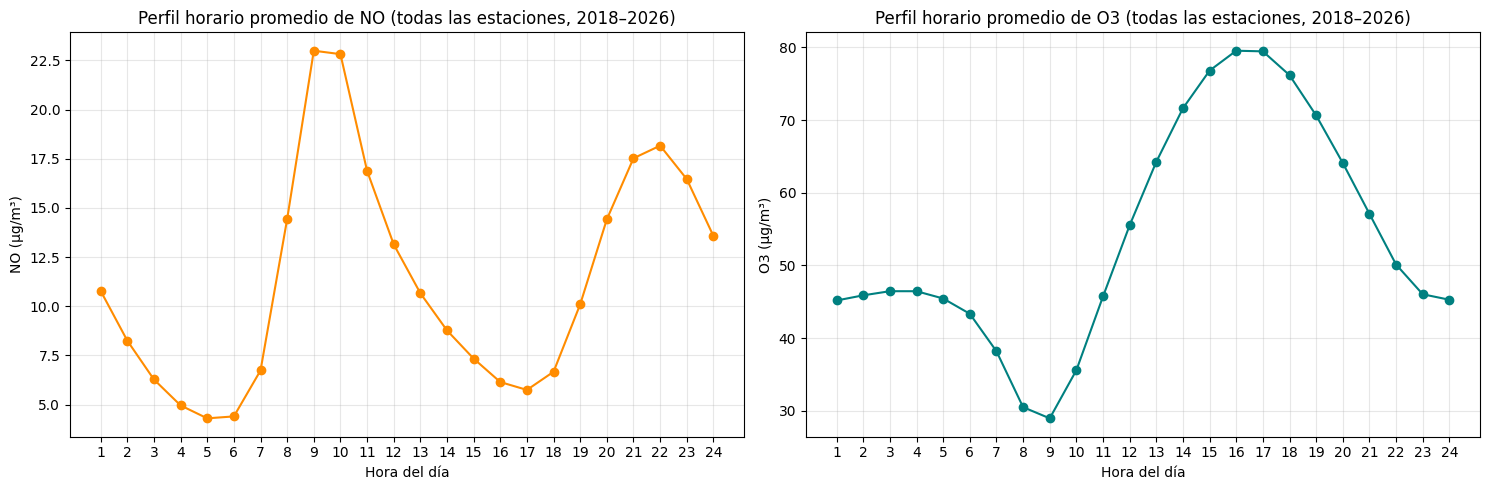

In [13]:
# Perfil horario promedio de NO y O3: la "predicción" más simple posible
perfil_horario = df_largo.groupby(['MAGNITUD', 'HORA'])['VALOR'].mean().unstack(level=0)
perfil_horario.columns = ['NO (Magnitud 7)', 'O3 (Magnitud 14)']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Graficar NO
perfil_horario['NO (Magnitud 7)'].plot(ax=axes[0], marker='o', color='darkorange')
axes[0].set_title('Perfil horario promedio de NO (todas las estaciones, 2018–2026)')
axes[0].set_xlabel('Hora del día')
axes[0].set_ylabel('NO (µg/m³)')
axes[0].set_xticks(range(1, 25))
axes[0].grid(alpha=0.3)

# Graficar O3
perfil_horario['O3 (Magnitud 14)'].plot(ax=axes[1], marker='o', color='teal')
axes[1].set_title('Perfil horario promedio de O3 (todas las estaciones, 2018–2026)')
axes[1].set_xlabel('Hora del día')
axes[1].set_ylabel('O3 (µg/m³)')
axes[1].set_xticks(range(1, 25))
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# Comparamos el perfil esperado contra un día real concreto: estación 8, 15/06/2024
ejemplo = df_largo[
    (df_largo['ESTACION'] == 8) &
    (df_largo['ANO'] == 2024) &
    (df_largo['MES'] == 6) &
    (df_largo['DIA'] == 15)
].sort_values(['MAGNITUD', 'HORA']).copy()

perfil_dict = {(mag, hora): val for (mag, hora), val in df_largo.groupby(['MAGNITUD', 'HORA'])['VALOR'].mean().items()}
ejemplo['valor_esperado'] = ejemplo.apply(lambda row: perfil_dict.get((row['MAGNITUD'], row['HORA'])), axis=1)
ejemplo['residuo'] = ejemplo['VALOR'] - ejemplo['valor_esperado']

print("Ejemplo de NO (Magnitud 7):")
print(ejemplo[ejemplo['MAGNITUD'] == 7][['HORA', 'VALOR', 'valor_esperado', 'residuo']])
print("\nEjemplo de O3 (Magnitud 14):")
print(ejemplo[ejemplo['MAGNITUD'] == 14][['HORA', 'VALOR', 'valor_esperado', 'residuo']])

Ejemplo de NO (Magnitud 7):
         HORA  VALOR  valor_esperado    residuo
87647       1    2.0       10.777815  -8.777815
200388      2    2.0        8.247986  -6.247986
313129      3    3.0        6.273032  -3.273032
425870      4    2.0        4.955134  -2.955134
538611      5    1.0        4.298092  -3.298092
651352      6    1.0        4.396161  -3.396161
764093      7    1.0        6.731111  -5.731111
876834      8    2.0       14.430044 -12.430044
989575      9    3.0       22.990449 -19.990449
1102316    10    3.0       22.816368 -19.816368
1215057    11    5.0       16.882609 -11.882609
1327798    12    4.0       13.141739  -9.141739
1440539    13    4.0       10.660098  -6.660098
1553280    14    3.0        8.768403  -5.768403
1666021    15    4.0        7.334409  -3.334409
1778762    16    3.0        6.143308  -3.143308
1891503    17    3.0        5.743245  -2.743245
2004244    18    4.0        6.666611  -2.666611
2116985    19    4.0       10.098601  -6.098601
2229726    2

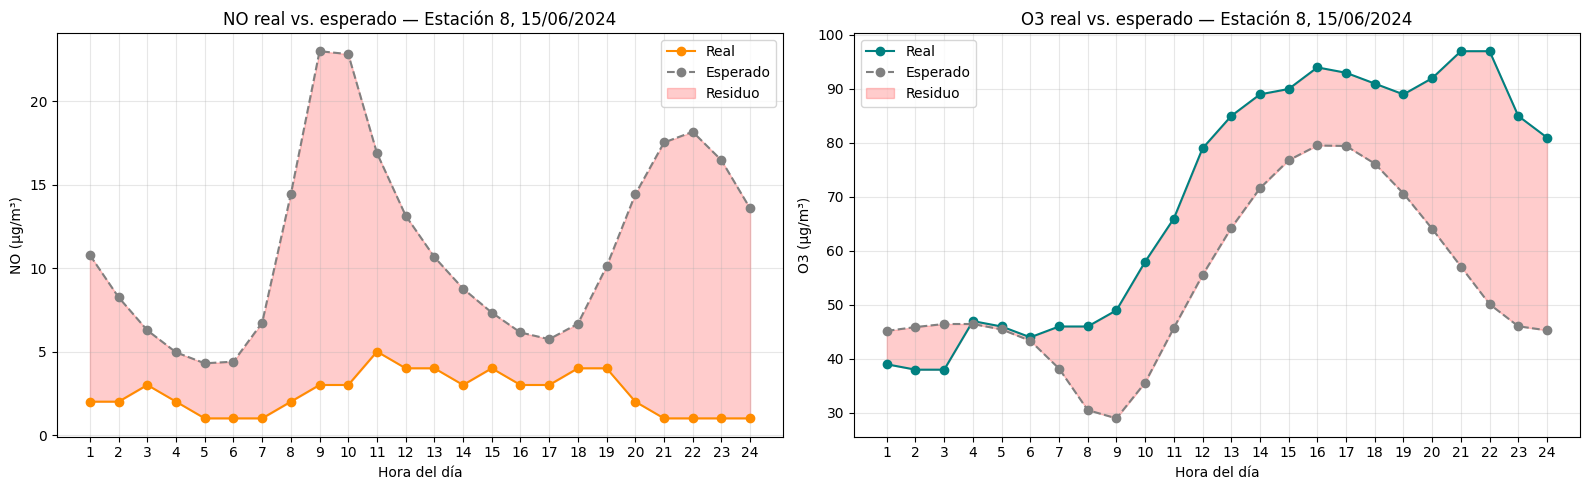

In [15]:
# Visualizamos real vs esperado, con el residuo sombreado para ambos contaminantes
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Graficar NO
ej_no = ejemplo[ejemplo['MAGNITUD'] == 7].sort_values('HORA')
axes[0].plot(ej_no['HORA'], ej_no['VALOR'], marker='o', label='Real', color='darkorange')
axes[0].plot(ej_no['HORA'], ej_no['valor_esperado'], marker='o', linestyle='--', label='Esperado', color='gray')
axes[0].fill_between(ej_no['HORA'], ej_no['VALOR'], ej_no['valor_esperado'], alpha=0.2, color='red', label='Residuo')
axes[0].set_title('NO real vs. esperado — Estación 8, 15/06/2024')
axes[0].set_xlabel('Hora del día')
axes[0].set_ylabel('NO (µg/m³)')
axes[0].set_xticks(range(1, 25))
axes[0].legend()
axes[0].grid(alpha=0.3)

# Graficar O3
ej_o3 = ejemplo[ejemplo['MAGNITUD'] == 14].sort_values('HORA')
axes[1].plot(ej_o3['HORA'], ej_o3['VALOR'], marker='o', label='Real', color='teal')
axes[1].plot(ej_o3['HORA'], ej_o3['valor_esperado'], marker='o', linestyle='--', label='Esperado', color='gray')
axes[1].fill_between(ej_o3['HORA'], ej_o3['VALOR'], ej_o3['valor_esperado'], alpha=0.2, color='red', label='Residuo')
axes[1].set_title('O3 real vs. esperado — Estación 8, 15/06/2024')
axes[1].set_xlabel('Hora del día')
axes[1].set_ylabel('O3 (µg/m³)')
axes[1].set_xticks(range(1, 25))
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Conclusiones y Relación Química entre el NO y el O3

Tras realizar el análisis exploratorio de datos (EDA) para el Monóxido de nitrógeno (NO) y el Ozono (O3), se pueden extraer las siguientes conclusiones clave:

### Comportamiento del Monóxido de Nitrógeno (NO)
* **Perfil Horario**: Presenta picos muy marcados en las horas punta de tráfico por la mañana (7:00 - 9:00h) y un aumento progresivo al final del día (20:00 - 22:00h). Esto refleja que el tráfico rodado es la fuente antropogénica principal de NO en la ciudad de Madrid.
* **Calidad de Datos**: Los sensores del contaminante NO muestran un bajo porcentaje de datos inválidos generalizado (alrededor de 1.02% en el período histórico), garantizando la consistencia temporal del análisis.

### Comportamiento del Ozono (O3)
* **Perfil Horario**: Muestra una dinámica inversa a la del NO. Su pico máximo ocurre durante las horas de máxima radiación solar y temperatura (14:00 - 17:00h), cayendo a valores mínimos de madrugada.
* **Dinámica Química**: El O3 es un contaminante secundario formado mediante reacciones fotoquímicas de óxidos de nitrógeno (NOx) y compuestos orgánicos volátiles en presencia de luz solar.

### Interacción y Correlación Negativa
* **Correlación Histórica**: Se ha calculado una correlación lineal negativa de **-0.4138** entre el NO y el O3.
* **Química Atmosférica**: Esta fuerte relación inversa es producto de la dinámica de los contaminantes en la troposfera:
  1. Durante la noche y primeras horas de la mañana, las emisiones masivas de NO reaccionan de inmediato con el O3 disponible destruyéndolo mediante el proceso de **titulación** ($NO + O_3 
ightarrow NO_2 + O_2$). Esto mantiene bajos los niveles de O3 cerca de las vías de tráfico.
  2. A mediodía, la intensa radiación solar desencadena la fotólisis del $NO_2$, produciendo átomos de oxígeno libres que forman ozono ($O_3$), mientras que el NO se dispersa o se convierte rápidamente.

### Implicaciones para la Detección de Anomalías
* El comportamiento esperado de ambos contaminantes depende críticamente de la **hora del día** y de las **condiciones del tráfico/luz**.
* Un modelo robusto para anomalías ambientales (como *Isolation Forest*) deberá modelar la interacción y la estacionalidad horaria de ambos gases conjuntamente, esperando residuos pequeños respecto al ciclo diario normal y considerando anomalía operacional cuando los patrones de titulación se rompan de forma anómala.